# Klasifikasi Tulisan Tangan EMNIST
## HOG Feature Extraction + SVM Classifier

**Alur:**
1. Load & visualisasi dataset EMNIST (2600 sampel, 26 kelas, masing-masing 100 sampel)
2. HOG Feature Extraction dengan parameter yang disesuaikan
3. Klasifikasi SVM dengan Grid Search
4. Evaluasi menggunakan LOOCV-style split (80% train / 20% test)
5. Confusion Matrix, Accuracy, Precision, Recall, F1-Score

In [2]:
# ── Import Library ──────────────────────────────────────────────────────────
import struct
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Semua library berhasil diimpor.')

Semua library berhasil diimpor.


## 1. Dataset Preparation

In [9]:
# ── Fungsi membaca file IDX binary EMNIST ───────────────────────────────────
def read_emnist_images(filepath):
    """Membaca file gambar IDX3-ubyte EMNIST."""
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f'Magic number salah: {magic}'
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def read_emnist_labels(filepath):
    """Membaca file label IDX1-ubyte EMNIST."""
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        assert magic == 2049, f'Magic number salah: {magic}'
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# ── Path dataset (sesuaikan jika berbeda) ───────────────────────────────────
IMAGES_PATH = 'E:/Semester 6 Robotika/RE604 COMPUTER VISION/comfis/emnist-letters-train-images-idx3-ubyte'
LABELS_PATH = 'E:/Semester 6 Robotika/RE604 COMPUTER VISION/comfis/emnist-letters-train-labels-idx1-ubyte'

print('Membaca dataset EMNIST...')
all_images = read_emnist_images(IMAGES_PATH)
all_labels = read_emnist_labels(LABELS_PATH)

print(f'Total gambar  : {all_images.shape[0]}')
print(f'Ukuran gambar : {all_images.shape[1]} x {all_images.shape[2]} piksel')
print(f'Total label   : {all_labels.shape[0]}')
print(f'Kelas unik    : {sorted(np.unique(all_labels))}  (1=A ... 26=Z)')

Membaca dataset EMNIST...
Total gambar  : 124800
Ukuran gambar : 28 x 28 piksel
Total label   : 124800
Kelas unik    : [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26)]  (1=A ... 26=Z)


In [10]:
# ── Transpose gambar: EMNIST disimpan column-major, perlu dibalik ───────────
# Setiap gambar perlu di-transpose agar tampil benar sebagai huruf
all_images = np.array([img.T for img in all_images])

# ── Ambil 100 sampel per kelas (26 kelas = 2600 sampel) ────────────────────
SAMPLES_PER_CLASS = 100
NUM_CLASSES = 26
TOTAL_SAMPLES = SAMPLES_PER_CLASS * NUM_CLASSES

selected_images = []
selected_labels = []

for cls in range(1, NUM_CLASSES + 1):
    idx = np.where(all_labels == cls)[0]
    chosen = np.random.choice(idx, size=SAMPLES_PER_CLASS, replace=False)
    selected_images.append(all_images[chosen])
    selected_labels.append(all_labels[chosen])

images = np.concatenate(selected_images, axis=0)   # (2600, 28, 28)
labels = np.concatenate(selected_labels, axis=0)   # (2600,)

# ── Konversi label 1-26 → 0-25 untuk konsistensi sklearn ──────────────────
labels = labels - 1   # 0=A, 1=B, ..., 25=Z

# ── Shuffle dataset ─────────────────────────────────────────────────────────
shuffle_idx = np.random.permutation(TOTAL_SAMPLES)
images = images[shuffle_idx]
labels = labels[shuffle_idx]

print(f'Dataset setelah seleksi & shuffle:')
print(f'  Jumlah sampel : {images.shape[0]}')
print(f'  Jumlah kelas  : {len(np.unique(labels))}')
unique, counts = np.unique(labels, return_counts=True)
print(f'  Distribusi kelas (seharusnya 100 semua): min={counts.min()}, max={counts.max()}')

Dataset setelah seleksi & shuffle:
  Jumlah sampel : 2600
  Jumlah kelas  : 26
  Distribusi kelas (seharusnya 100 semua): min=100, max=100


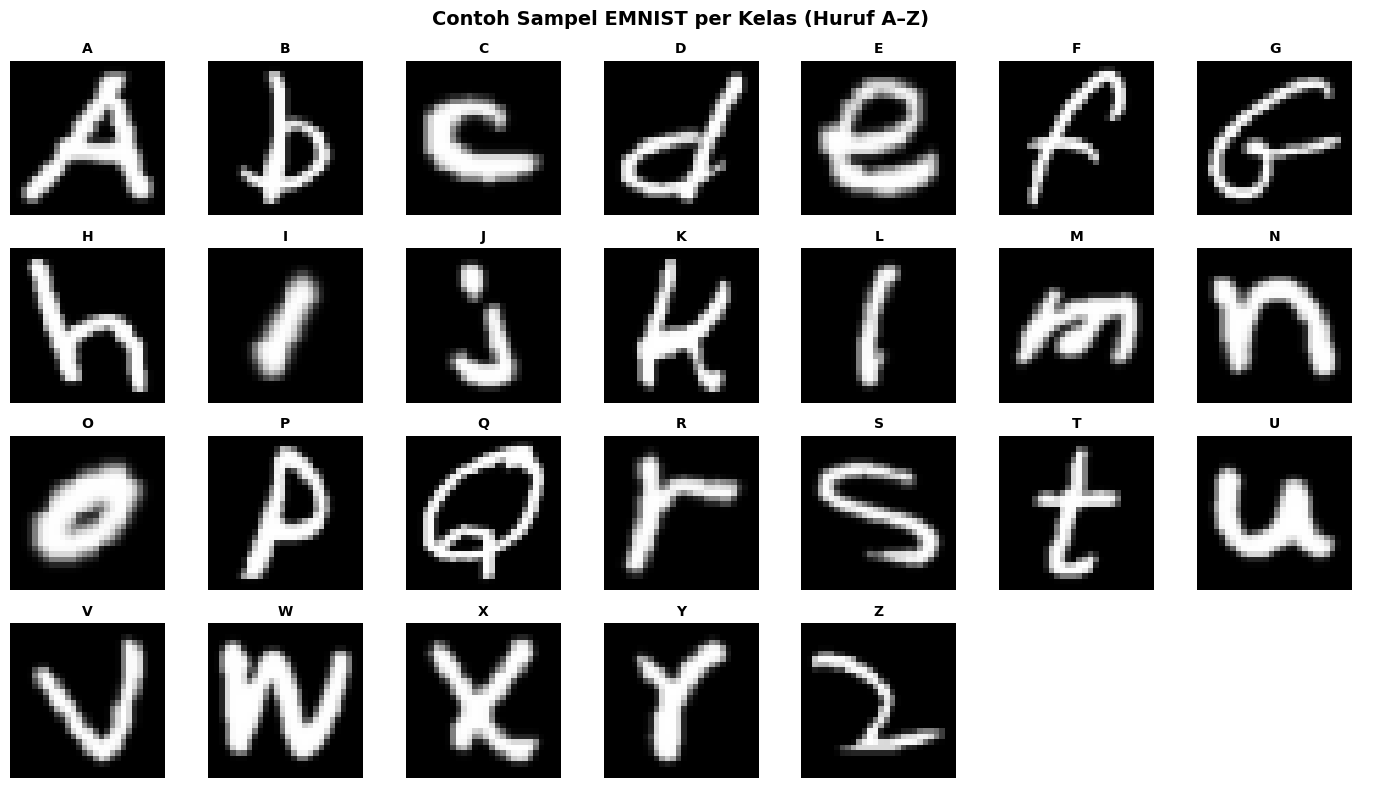

Visualisasi sampel gambar selesai.


In [11]:
# ── Visualisasi sampel gambar dari setiap kelas ─────────────────────────────
CLASS_NAMES = [chr(ord('A') + i) for i in range(26)]

fig, axes = plt.subplots(4, 7, figsize=(14, 8))
fig.suptitle('Contoh Sampel EMNIST per Kelas (Huruf A–Z)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < NUM_CLASSES:
        cls_idx = np.where(labels == idx)[0][0]
        ax.imshow(images[cls_idx], cmap='gray')
        ax.set_title(CLASS_NAMES[idx], fontsize=10, fontweight='bold')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visualisasi sampel gambar selesai.')

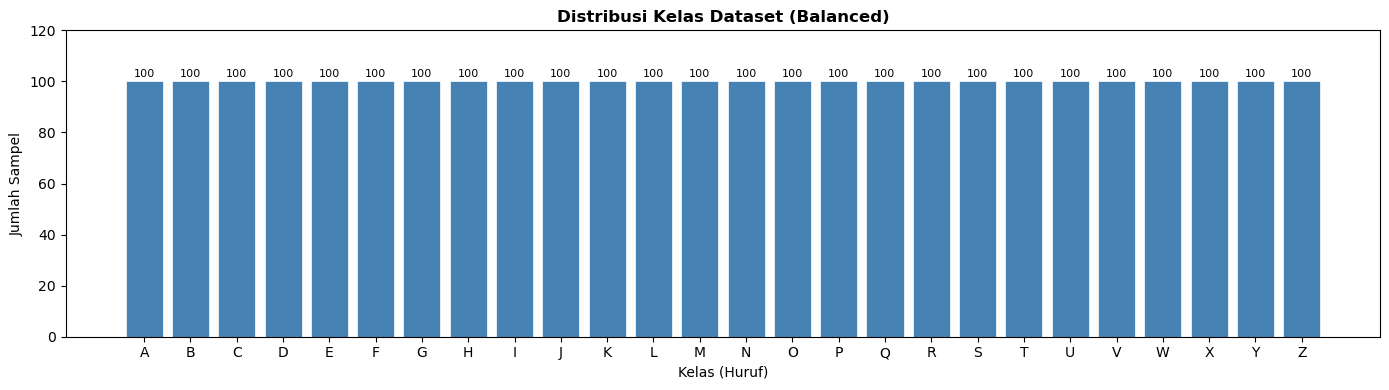

In [12]:
# ── Distribusi kelas ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
counts_per_class = [np.sum(labels == i) for i in range(NUM_CLASSES)]
bars = ax.bar(CLASS_NAMES, counts_per_class, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Distribusi Kelas Dataset (Balanced)', fontsize=12, fontweight='bold')
ax.set_xlabel('Kelas (Huruf)')
ax.set_ylabel('Jumlah Sampel')
ax.set_ylim(0, 120)
for bar, cnt in zip(bars, counts_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Feature Extraction – HOG (Histogram of Oriented Gradients)

Parameter HOG yang digunakan:
  orientations        : 12
  pixels_per_cell     : (7, 7)
  cells_per_block     : (2, 2)
  block_norm          : L2-Hys
  transform_sqrt      : True
  feature_vector      : True


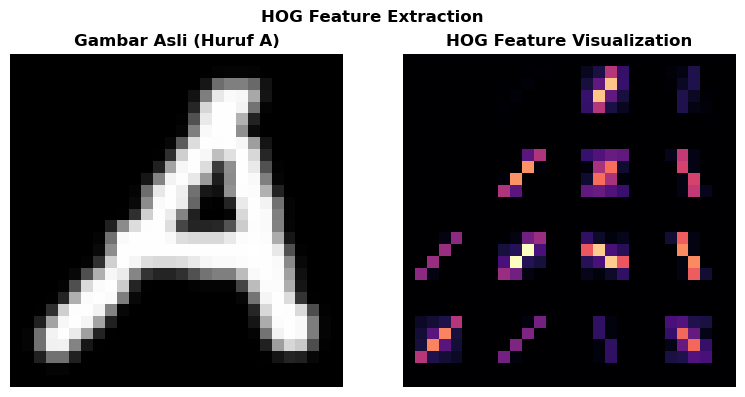

Dimensi fitur HOG per gambar: 432


In [13]:
# ── Parameter HOG yang telah di-tuning ─────────────────────────────────────
HOG_PARAMS = {
    'orientations'   : 12,      # default=9; lebih banyak arah gradien
    'pixels_per_cell': (7, 7),  # default=(8,8); sel lebih kecil → detail lebih baik
    'cells_per_block': (2, 2),  # default=(3,3); normalisasi lokal 2×2
    'block_norm'     : 'L2-Hys',
    'transform_sqrt' : True,    # reduksi pengaruh pencahayaan
    'feature_vector' : True,
}

print('Parameter HOG yang digunakan:')
for k, v in HOG_PARAMS.items():
    print(f'  {k:20s}: {v}')

# ── Visualisasi HOG pada satu contoh gambar ─────────────────────────────────
sample_img = images[np.where(labels == 0)[0][0]]   # huruf A
sample_img_norm = sample_img.astype(np.float32) / 255.0

fd, hog_img = hog(
    sample_img_norm,
    **{k: v for k, v in HOG_PARAMS.items() if k != 'feature_vector'},
    visualize=True,
    feature_vector=True
)
hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(sample_img, cmap='gray')
ax1.set_title('Gambar Asli (Huruf A)', fontweight='bold')
ax1.axis('off')
ax2.imshow(hog_img_rescaled, cmap='magma')
ax2.set_title('HOG Feature Visualization', fontweight='bold')
ax2.axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('hog_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Dimensi fitur HOG per gambar: {fd.shape[0]}')

In [14]:
# ── Ekstraksi HOG untuk seluruh dataset ─────────────────────────────────────
print('Mengekstraksi fitur HOG untuk 2600 gambar...')

def extract_hog_features(imgs, params):
    features = []
    for img in imgs:
        img_norm = img.astype(np.float32) / 255.0
        fd = hog(img_norm, **params)
        features.append(fd)
    return np.array(features)

X = extract_hog_features(images, HOG_PARAMS)
y = labels

print(f'Shape fitur HOG: {X.shape}  →  {X.shape[0]} sampel × {X.shape[1]} fitur')

Mengekstraksi fitur HOG untuk 2600 gambar...
Shape fitur HOG: (2600, 432)  →  2600 sampel × 432 fitur


## 3. LOOCV-style Split (80% Train / 20% Test)

In [15]:
# ── Split 80% Train / 20% Test (stratified) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print('Pembagian dataset:')
print(f'  Train : {X_train.shape[0]} sampel  ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'  Test  : {X_test.shape[0]}  sampel  ({X_test.shape[0]/len(y)*100:.0f}%)')

# ── Standarisasi fitur ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Standarisasi fitur selesai (StandardScaler).')

Pembagian dataset:
  Train : 2080 sampel  (80%)
  Test  : 520  sampel  (20%)
Standarisasi fitur selesai (StandardScaler).


## 4. Klasifikasi SVM + Grid Search

In [16]:
# ── Grid Search untuk menemukan parameter SVM terbaik ──────────────────────
# Menggunakan StratifiedKFold 5-fold sebagai inner CV (pendekatan LOOCV efisien)

param_grid = {
    'kernel': ['rbf', 'poly'],          # tipe kernel
    'C'     : [0.1, 1.0, 10.0, 100.0], # regularisasi
    'gamma' : ['scale', 'auto', 0.001], # koefisien kernel
}

print('Parameter Grid yang dicari:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid=param_grid,
    cv=cv_inner,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print('\nMemulai Grid Search (ini membutuhkan beberapa menit)...')
grid_search.fit(X_train_scaled, y_train)

print('\n✓ Grid Search selesai!')
print(f'Parameter terbaik : {grid_search.best_params_}')
print(f'CV Accuracy (train): {grid_search.best_score_:.4f}')

Parameter Grid yang dicari:
  kernel: ['rbf', 'poly']
  C: [0.1, 1.0, 10.0, 100.0]
  gamma: ['scale', 'auto', 0.001]

Memulai Grid Search (ini membutuhkan beberapa menit)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Grid Search selesai!
Parameter terbaik : {'C': 10.0, 'gamma': 0.001, 'kernel': 'rbf'}
CV Accuracy (train): 0.8192


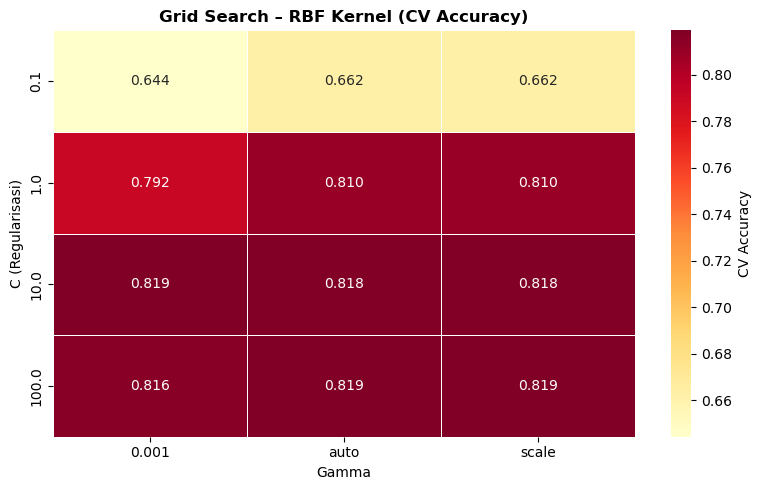

In [17]:
# ── Visualisasi hasil Grid Search ──────────────────────────────────────────
import pandas as pd

results_df = pd.DataFrame(grid_search.cv_results_)
pivot_rbf = results_df[results_df['param_kernel'] == 'rbf'].pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_rbf, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CV Accuracy'})
ax.set_title('Grid Search – RBF Kernel (CV Accuracy)', fontweight='bold')
ax.set_xlabel('Gamma')
ax.set_ylabel('C (Regularisasi)')
plt.tight_layout()
plt.savefig('grid_search_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
# ── Model terbaik dari Grid Search ─────────────────────────────────────────
best_svm = grid_search.best_estimator_
print('Model SVM terbaik:')
print(best_svm)

Model SVM terbaik:
SVC(C=10.0, class_weight='balanced', gamma=0.001, probability=True,
    random_state=42)


## 5. Evaluasi Performa

In [19]:
# ── Fungsi helper untuk menampilkan metrik ──────────────────────────────────
def print_metrics(y_true, y_pred, title=''):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f'{'='*55}')
    print(f'  {title}')
    print(f'{'='*55}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'{'='*55}')
    return acc, prec, rec, f1

In [20]:
# ── Evaluasi pada data TRAIN ────────────────────────────────────────────────
y_train_pred = best_svm.predict(X_train_scaled)
train_metrics = print_metrics(y_train, y_train_pred, 'PERFORMA TRAINING (80%)')

  PERFORMA TRAINING (80%)
  Accuracy  : 0.9976  (99.76%)
  Precision : 0.9977
  Recall    : 0.9976
  F1-Score  : 0.9976


In [21]:
# ── Evaluasi pada data TEST ─────────────────────────────────────────────────
y_test_pred = best_svm.predict(X_test_scaled)
test_metrics = print_metrics(y_test, y_test_pred, 'PERFORMA TESTING (20%)')

  PERFORMA TESTING (20%)
  Accuracy  : 0.8212  (82.12%)
  Precision : 0.8291
  Recall    : 0.8212
  F1-Score  : 0.8210


In [22]:
# ── Classification Report lengkap ──────────────────────────────────────────
print('\nClassification Report (Test Set):')
print(classification_report(
    y_test, y_test_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))


Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.61      0.70      0.65        20
           B       0.89      0.85      0.87        20
           C       0.71      0.85      0.77        20
           D       0.80      0.80      0.80        20
           E       0.89      0.80      0.84        20
           F       0.95      0.90      0.92        20
           G       0.57      0.40      0.47        20
           H       0.68      0.85      0.76        20
           I       0.61      0.70      0.65        20
           J       0.81      0.85      0.83        20
           K       1.00      0.75      0.86        20
           L       0.61      0.55      0.58        20
           M       0.91      1.00      0.95        20
           N       0.83      0.75      0.79        20
           O       0.83      0.95      0.88        20
           P       1.00      0.85      0.92        20
           Q       0.62      0.75      0.68   

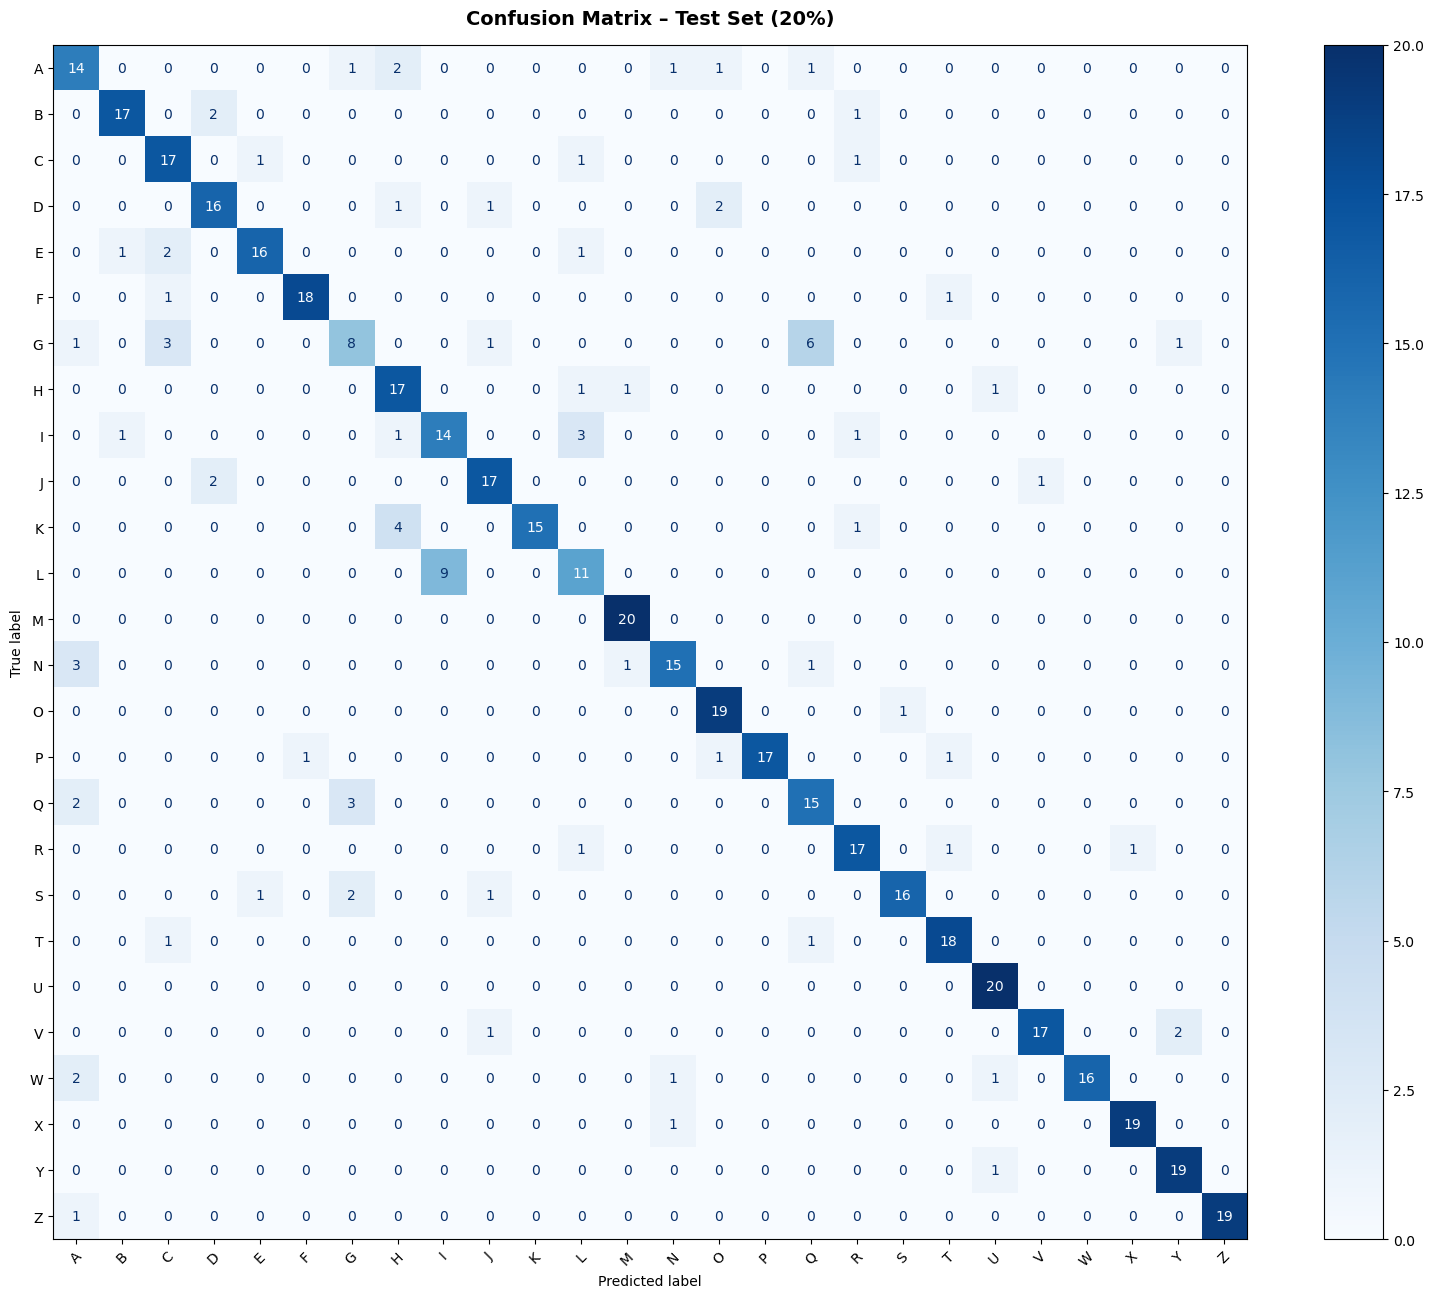

In [23]:
# ── Confusion Matrix – TEST SET ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(16, 13))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix – Test Set (20%)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=120, bbox_inches='tight')
plt.show()

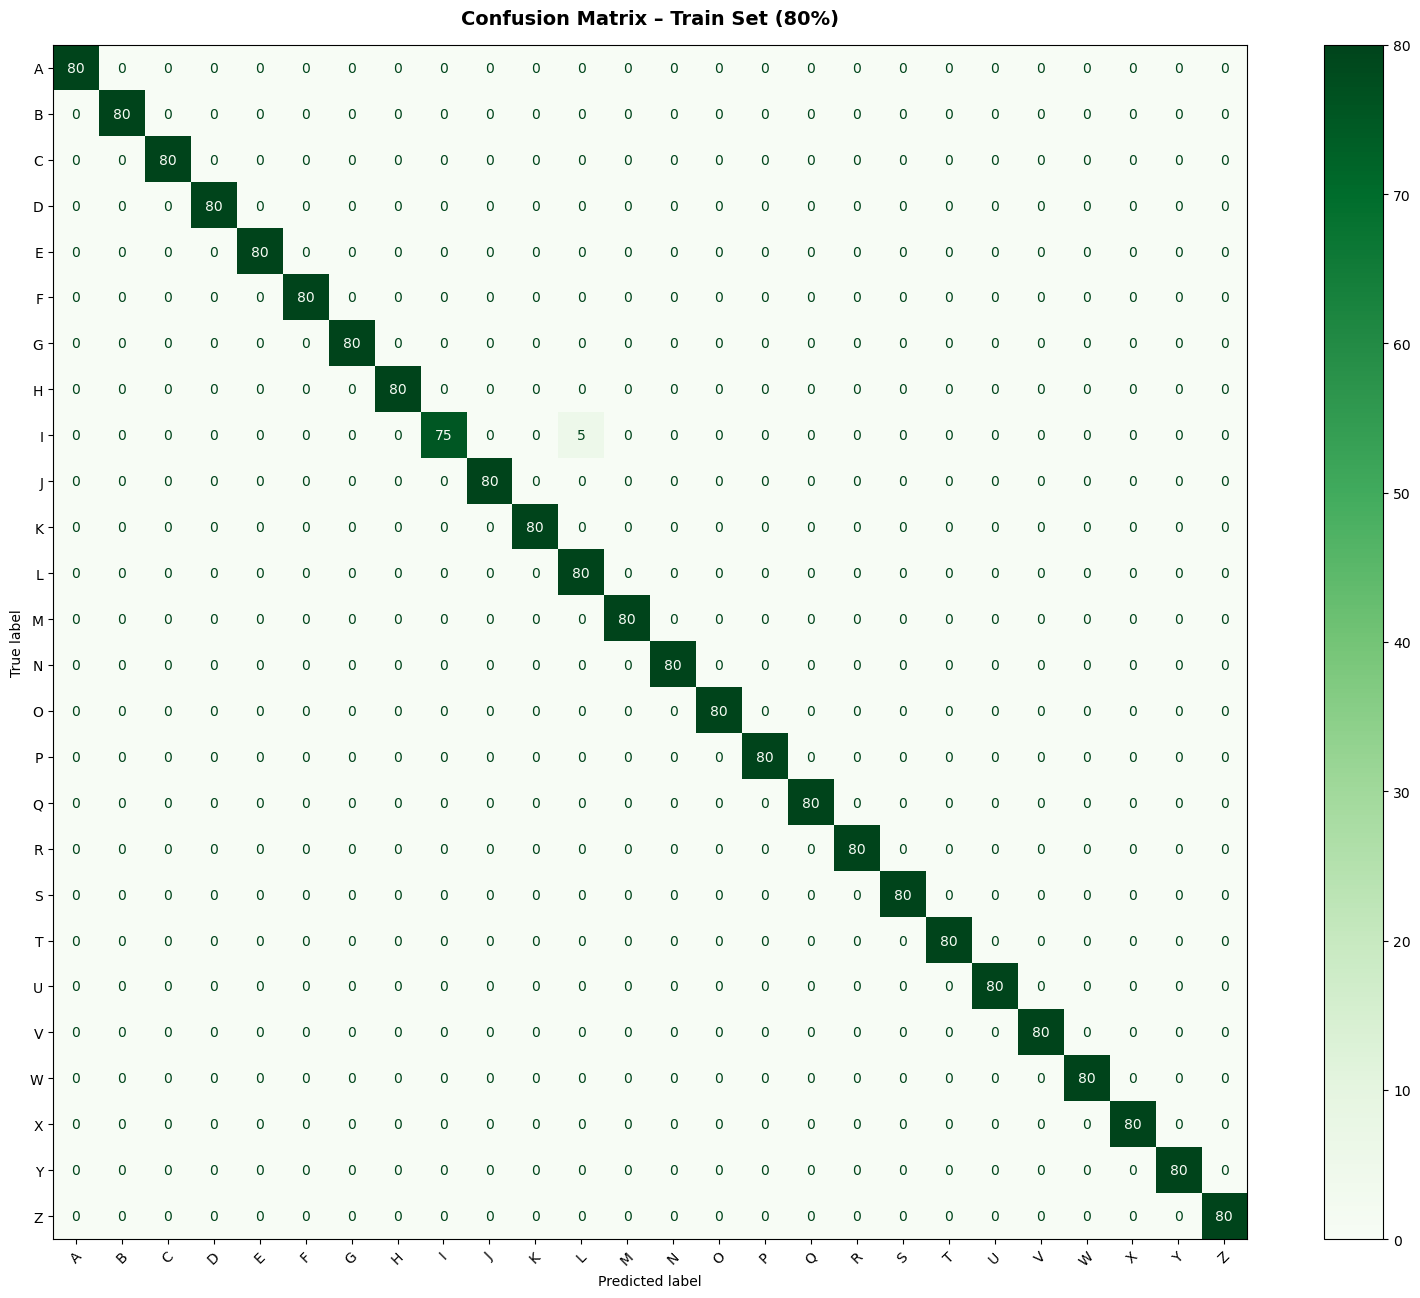

In [24]:
# ── Confusion Matrix – TRAIN SET ────────────────────────────────────────────
cm_train = confusion_matrix(y_train, y_train_pred)

fig, ax = plt.subplots(figsize=(16, 13))
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=CLASS_NAMES)
disp_train.plot(ax=ax, cmap='Greens', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix – Train Set (80%)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix_train.png', dpi=120, bbox_inches='tight')
plt.show()

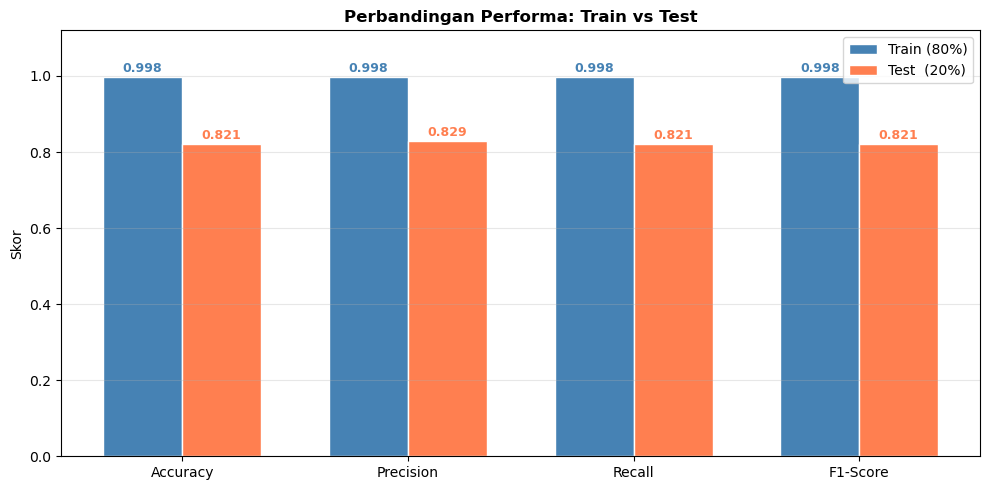

In [25]:
# ── Perbandingan Metrik Train vs Test ──────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals = list(train_metrics)
test_vals  = list(test_metrics)

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train (80%)', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, test_vals,  width, label='Test  (20%)', color='coral',     edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='steelblue', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='coral', fontweight='bold')

ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa: Train vs Test', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.12)
ax.legend()
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

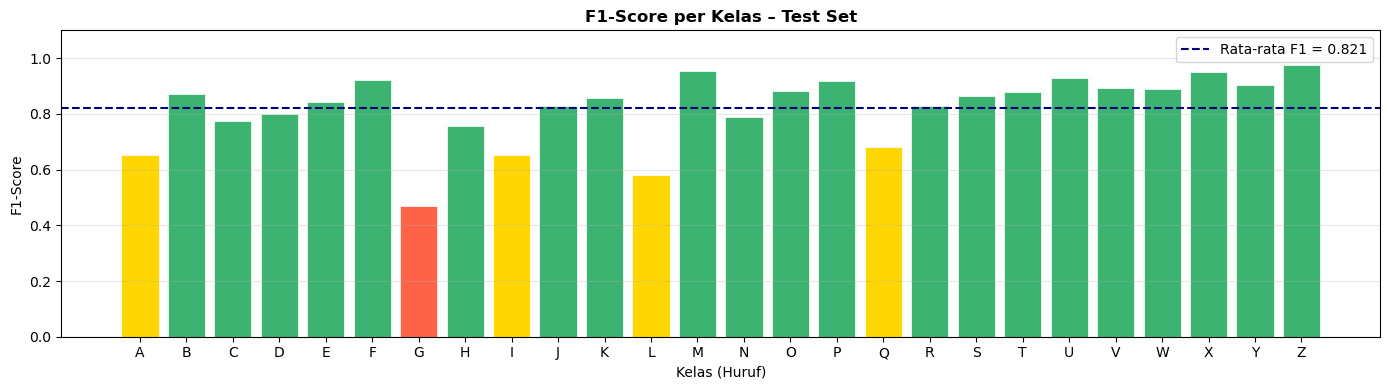

5 kelas dengan F1-Score terendah : ['G', 'L', 'I', 'A', 'Q']
5 kelas dengan F1-Score tertinggi: ['Z', 'M', 'X', 'U', 'F']


In [26]:
# ── Per-kelas F1-Score pada test set ───────────────────────────────────────
f1_per_class = f1_score(y_test, y_test_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['tomato' if v < 0.5 else 'gold' if v < 0.7 else 'mediumseagreen' for v in f1_per_class]
ax.bar(CLASS_NAMES, f1_per_class, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=f1_per_class.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Rata-rata F1 = {f1_per_class.mean():.3f}')
ax.set_title('F1-Score per Kelas – Test Set', fontsize=12, fontweight='bold')
ax.set_xlabel('Kelas (Huruf)')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

worst_5  = np.argsort(f1_per_class)[:5]
best_5   = np.argsort(f1_per_class)[-5:][::-1]
print('5 kelas dengan F1-Score terendah :', [CLASS_NAMES[i] for i in worst_5])
print('5 kelas dengan F1-Score tertinggi:', [CLASS_NAMES[i] for i in best_5])

In [27]:
# ── Ringkasan Akhir ─────────────────────────────────────────────────────────
print('\n' + '█'*60)
print('  RINGKASAN EKSPERIMEN')
print('█'*60)
print(f'\n  Dataset       : EMNIST Letters')
print(f'  Total Sampel  : 2600  (26 kelas × 100 sampel)')
print(f'  Split         : 80% Train / 20% Test (stratified)')
print(f'\n  HOG Parameters:')
for k, v in HOG_PARAMS.items():
    print(f'    {k:20s}: {v}')
print(f'  HOG Feature Dim: {X.shape[1]}')
print(f'\n  SVM Best Params: {grid_search.best_params_}')
print(f'  CV Best Score  : {grid_search.best_score_:.4f}')
print(f'\n  TRAIN SET:')
print(f'    Accuracy  = {train_metrics[0]:.4f}')
print(f'    Precision = {train_metrics[1]:.4f}')
print(f'    Recall    = {train_metrics[2]:.4f}')
print(f'    F1-Score  = {train_metrics[3]:.4f}')
print(f'\n  TEST SET:')
print(f'    Accuracy  = {test_metrics[0]:.4f}')
print(f'    Precision = {test_metrics[1]:.4f}')
print(f'    Recall    = {test_metrics[2]:.4f}')
print(f'    F1-Score  = {test_metrics[3]:.4f}')
print('\n' + '█'*60)


████████████████████████████████████████████████████████████
  RINGKASAN EKSPERIMEN
████████████████████████████████████████████████████████████

  Dataset       : EMNIST Letters
  Total Sampel  : 2600  (26 kelas × 100 sampel)
  Split         : 80% Train / 20% Test (stratified)

  HOG Parameters:
    orientations        : 12
    pixels_per_cell     : (7, 7)
    cells_per_block     : (2, 2)
    block_norm          : L2-Hys
    transform_sqrt      : True
    feature_vector      : True
  HOG Feature Dim: 432

  SVM Best Params: {'C': 10.0, 'gamma': 0.001, 'kernel': 'rbf'}
  CV Best Score  : 0.8192

  TRAIN SET:
    Accuracy  = 0.9976
    Precision = 0.9977
    Recall    = 0.9976
    F1-Score  = 0.9976

  TEST SET:
    Accuracy  = 0.8212
    Precision = 0.8291
    Recall    = 0.8212
    F1-Score  = 0.8210

████████████████████████████████████████████████████████████
